In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model 

In [17]:
df = pd.read_csv("C:/Users/minha/Downloads/canada_per_capita_income.csv")
df.head()


,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


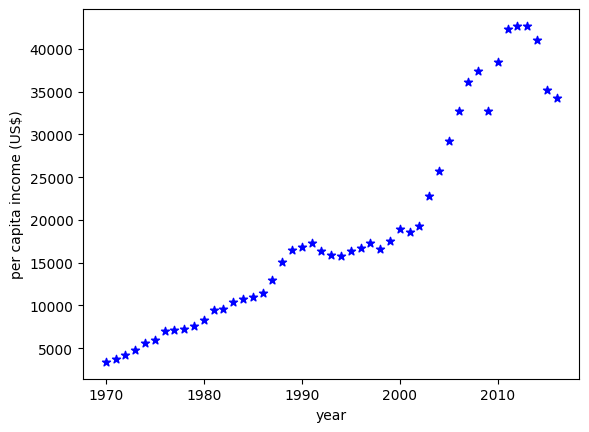

In [23]:
%matplotlib inline
plt.xlabel("year")
plt.ylabel('per capita income (US$)')
plt.scatter(df['year'], df['per capita income (US$)'], color='blue', marker='*')
plt.savefig("C:/Users/minha/Downloads/scatter_plot.png") #saving the graph

In [27]:
reg = linear_model.LinearRegression()
reg.fit(df[['year']], df['per capita income (US$)'])

LinearRegression()

In [28]:
reg.predict([[2020]])

C:\Users\minha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([41288.69409442])

In [29]:
new_df = pd.DataFrame({'year': [2025]})  #to counter the warning
reg.predict(new_df)

array([45431.01947053])

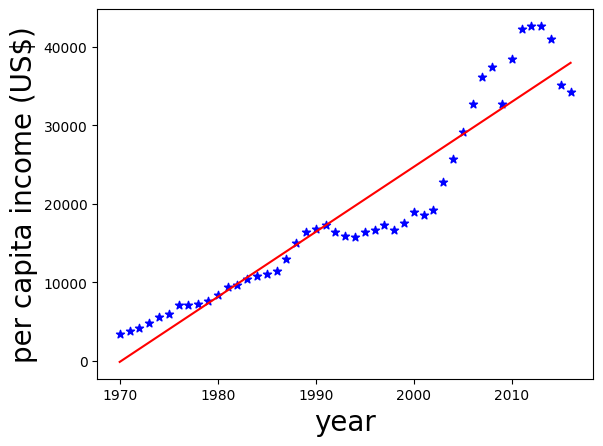

In [30]:
%matplotlib inline
plt.xlabel("year", fontsize=20)
plt.ylabel('per capita income (US$)', fontsize=20)

plt.scatter(df['year'], df['per capita income (US$)'], color='blue', marker='*')

plt.plot(df['year'], reg.predict(df[['year']]), color='red')

plt.savefig("C:/Users/minha/Downloads/linear_regression_fit.png")  # save image

plt.show()

In [32]:
reg.coef_


array([828.46507522])

In [33]:
reg.intercept_

np.float64(-1632210.7578554575)

In [34]:
828.46507522*2020+(-1632210.7578554575)

41288.694088942604

In [38]:
# Predict income for the year 2020
# Using DataFrame to avoid sklearn warning
pred_2020 = reg.predict(pd.DataFrame([[2020]], columns=['year']))

# Create a new row with year = 2020 and predicted income
new_row = pd.DataFrame({
    'year': [2020],
    'per capita income (US$)': [pred_2020[0]]  # extract value from array
})

# Add this new row to the existing dataset
df = pd.concat([df, new_row], ignore_index=True)

# (Optional but recommended) Sort data by year after adding new row
df = df.sort_values(by='year')

# Save the updated dataset into a new CSV file
df.to_csv("C:/Users/minha/Downloads/linear_regression_updated_dataset.csv", index=False)

# Print message to confirm everything worked
print("✅ 2020 predicted value added and file saved successfully!")


✅ 2020 predicted value added and file saved successfully!
